In [2]:
import numpy as np
import h5py
import time
import datetime

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from dataset_generation.make_orbits import *
from helpers.config import *
from pytdi.michelson import *
from pytdi import LISATDICombination
from scipy.signal import welch

from lisaorbits import KeplerianOrbits, EqualArmlengthOrbits, OEMOrbits
from lisaglitch import LPFLibraryGlitch
from scipy.signal import coherence

import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/gwaves_lisa_py311/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1
OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [8]:
orbits_path2 = DIST / 'orbits' / 'orbits_trial.h5'
orb = h5py.File(orbits_path2, "r")
orb_size = orb.attrs['size']
orb_dt = orb.attrs['dt']

In [14]:
orb.close()

In [9]:
x = orb['tcb/x'][:]
r1 = x[:,0,:]
r2 = x[:,1,:]
r3 = x[:,2,:]

In [10]:
L12 = np.linalg.norm(r1 - r2, axis=1)
L23 = np.linalg.norm(r2 - r3, axis=1)
L31 = np.linalg.norm(r3 - r1, axis=1)

print(f'L12: {L12[0]:.4e}')
print(f'L23: {L23[0]:.4e}')
print(f'L31: {L31[0]:.4e}')

L12: 2.4922e+09
L23: 2.4973e+09
L31: 2.4904e+09


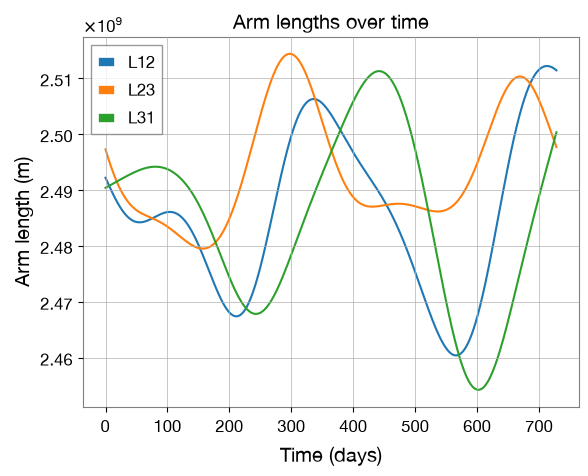

In [11]:
t = np.arange(0, orb_size*orb_dt, orb_dt)
plt.plot(t/86400, L12)
plt.plot(t/86400, L23)
plt.plot(t/86400, L31)
plt.xlabel('Time (days)')
plt.ylabel('Arm length (m)')
plt.title('Arm lengths over time')
plt.legend(['L12', 'L23', 'L31'])
plt.show()

In [28]:
orb.close()

In [22]:
orb_size*orb_dt/(86400)*0.01

np.float64(14.594907407407407)

In [5]:
h5file = create_mixed_dataset(MIXED_DATASETS / 'mixed_dataset2.h5', siglen=PIPE['size'])

lim = 1001
with h5py.File(mixed_dataset_path, 'r') as h5:
    X_array = h5["X"][:lim]       # shape (N, 512, 512)
    Y_array = h5["Y"][:lim]       # shape (N, 512, 512)
    Z_array = h5["Z"][:lim]
    level_array = h5["amp"][:lim]
    beta_array = h5["beta"][:lim]
    inj_point_array = h5["inj_point"][:lim]
    m1_array = h5["m1"][:lim]
    m2_array = h5["m2"][:lim]
    d_array = h5["d"][:lim]
    spin1_array = h5["spin1"][:lim]
    spin2_array = h5["spin2"][:lim]
    gw_beta_array = h5["gw_beta"][:lim]
    gw_lambda_array = h5["gw_lambda"][:lim]
    sep_array = h5["sep"][:lim]
    t0_array = h5["t0"][:lim]

tdi_dict = {}
tdi_dict['X'] = X_array
tdi_dict['Y'] = Y_array
tdi_dict['Z'] = Z_array
append_mixed_sample(h5file, tdi_dict, m1_array, m2_array, d_array, spin1_array, spin2_array,
                    gw_beta_array, gw_lambda_array, level_array, beta_array, inj_point_array,
                    sep_array, t0_array)

In [2]:
h5file = create_gw_dataset(GW_DATASETS / 'gw_dataset.h5', siglen=PIPE['size'])

lim = 1001
with h5py.File(GW_DATASETS / 'gw_dataset3.h5', 'r') as h5:
    X_array = h5["X"][:lim]       # shape (N, 512, 512)
    Y_array = h5["Y"][:lim]       # shape (N, 512, 512)
    Z_array = h5["Z"][:lim]
    m1_array = h5["m1"][:lim]
    m2_array = h5["m2"][:lim]
    d_array = h5["d"][:lim]
    spin1_array = h5["spin1"][:lim]
    spin2_array = h5["spin2"][:lim]
    gw_beta_array = h5["gw_beta"][:lim]
    gw_lambda_array = h5["gw_lambda"][:lim]
    t0_array = h5["t0"][:lim]

tdi_dict = {}
tdi_dict['X'] = X_array
tdi_dict['Y'] = Y_array
tdi_dict['Z'] = Z_array
append_gw_sample(h5file, tdi_dict, m1_array, m2_array, d_array, spin1_array, spin2_array,
                    gw_beta_array, gw_lambda_array, t0_array)

In [4]:
h5file.close()